In [24]:
# Set up logging to display in Jupyter Notebook
import logging

logging.basicConfig(
    level=logging.ERROR,  # Show ERROR and above
    format="%(levelname)s: %(message)s",  # Format: "ERROR: message"
    force=True,  # Needed in Jupyter to reset config
)

In [25]:
import numpy as np
import cvxpy as cp
from scipy.spatial.distance import jensenshannon

In [26]:
import sys
sys.path.append("../")

In [27]:
from flow.solve_mix import *
from flow.interface import *
from utils.handy_states import *

## Define the input states

In [29]:
state_dict = sv_simple_2(0.2, 0.5, 0.7)
num_qubits = state_dict["num_qubits"]
num_states = state_dict["num_states"]
state_vec = state_dict["states"]
dense_mat = [DensityMatrix(_) for _ in state_vec]

In [30]:
#'''
num_qubits = 1
num_states = 2

state_vec = [
    Statevector([1, 0]),
    Statevector([1/np.sqrt(2), 1/np.sqrt(2)]),
]
dense_mat = [DensityMatrix(_) for _ in state_vec]
#'''


'\nnum_qubits = 1\nnum_states = 2\n\nstate_vec = [\n    Statevector([1, 0]),\n    Statevector([1/np.sqrt(2), 1/np.sqrt(2)]),\n]\ndense_mat = [DensityMatrix(_) for _ in state_vec]\n'

In [31]:
qsd_problem = ProblemSpec(
    num_qubits=num_qubits,
    num_states=num_states,
    case_id="0813_test",
    state_type="densitymatrix",
)

In [32]:
n = qsd_problem.num_states
# Comment/uncomment to switch between different prior probabilities
prior_prob = np.ones(n) * (1 / n)
# prior_prob = [1/9, 3/9, 5/9]
qsd_problem.prior_prob = prior_prob

In [33]:
qsd_problem.set_states(
    state_type="statevector",
    states=state_vec,
    overwrite=True,
)
ideal_result = apply_Eldar(
    problem_spec=qsd_problem,
    prior_prob=prior_prob,
    cvxpy_settings={
        "solver": cp.MOSEK,
        "verbose": False,
        "eps": 1e-8,
    }
)

ideal_distrib = calculate_prob_matrix_simple(
    prior_probs=prior_prob,
    povm=ideal_result["povm"],
    states=dense_mat,
)
uqsd_opt_val = ideal_result["p_succ"]
print(ideal_result["p_succ"])

0.8108931335061406


In [34]:
noise_levels = [0.1 ** (6 - 0.5 * i) for i in range(11)]
disturbance_states = [
    DensityMatrix(
        ProblemSpec.depolarizing_noise_channel(num_qubits=num_qubits)
    )
    for _ in range(num_states)
]

In [35]:
def get_sqrt_dist(a, b):
    return np.sqrt(sum([abs(a[i] - b[i]) ** 2 for i in range(len(a))]))


def run_qsd(
    qsd_problem: ProblemSpec,
    cvxpy_problem,
    jsd_result,
    sqrtd_result,
    psucc_result,
    eps=1e-8,
):
    cvxpy_settings = {"solver": cp.MOSEK, "verbose": False, "eps": eps}
    cvxpy_problem.solve(**cvxpy_settings)

    # print(cvxpy_problem.status)
    # print(cvxpy_problem.solution.opt_val)
    vars = cvxpy_problem.variables()

    fitqd_povm = [var.value for var in vars]
    # print(fitqd_povm)

    prob_mat = calculate_prob_matrix_simple(
        prior_probs=prior_prob,
        povm=fitqd_povm,
        states=qsd_problem.states,
    )
    # print(prob_mat)

    psucc = 0
    for i in range(qsd_problem.num_states):
        psucc += prob_mat[i][i]
    psucc_result.append(psucc)

    js_dist = jensenshannon(
        np.array(ideal_distrib).flatten(),
        np.array(prob_mat).flatten(),
    )
    jsd_result.append(js_dist)

    sqrt_dist = get_sqrt_dist(
        np.array(ideal_distrib).flatten(),
        np.array(prob_mat).flatten(),
    )
    sqrtd_result.append(sqrt_dist)
    #
    # print("alpha", np.array(calculate_errors(prob_mat)[0]))
    # print("beta ", max(calculate_errors(prob_mat)[1]))
    #
    # print()

In [36]:
cvxpy_settings = {"solver": cp.MOSEK, "verbose": False, "eps": 1e-8}
qsd_problem.set_states(
    state_type="densitymatrix",
    states=dense_mat,
    overwrite=True,
)
cvxpy_med_problem = med_problem(problem_spec=qsd_problem, prior_prob=prior_prob)
cvxpy_med_problem.solve(**cvxpy_settings)
med_opt_val = cvxpy_med_problem.solution.opt_val
print(med_opt_val)

0.9859781683017097


In [ ]:
jsd_result = []
sqrtd_result = []
psucc_result = []
eps_list = [1e-8]
lamdah_list = [0, 0.0001, 0.001, 0.01, 0.1, 1]
lamdah_list = [0.1 * _ for _ in range(10)]
lamdah_list = [0.3 + 0.02 * _ for _ in range(11)]
noise_levels = [0.1 ** (6 - 0.5 * i) for i in range(11)]
psucc_result_list = []
sqrtd_result_list = []

for param_a in lamdah_list:
    for eps in eps_list:
        jsd_result = []
        sqrtd_result = []
        psucc_result = []
        for noise_level in noise_levels:
            combined_states = [
                (1 - noise_level) * dense_mat[_]
                + noise_level * disturbance_states[_].data
                for _ in range(num_states)
            ]

            qsd_problem.set_states(
                state_type="densitymatrix",
                states=combined_states,
                overwrite=True,
            )

            cvxpy_problem = balance_obj_problem(
                problem_spec=qsd_problem,
                ideal_distrib=ideal_distrib,
                param_a=param_a,
            )

            run_qsd(
                qsd_problem=qsd_problem,
                cvxpy_problem=cvxpy_problem,
                jsd_result=jsd_result,
                sqrtd_result=sqrtd_result,
                psucc_result=psucc_result,
            )
        psucc_result_list.append(psucc_result)
        sqrtd_result_list.append(sqrtd_result)


lamdah = 0.3
eps = 1e-08

lamdah = 0.32
eps = 1e-08

lamdah = 0.33999999999999997
eps = 1e-08

lamdah = 0.36
eps = 1e-08

lamdah = 0.38
eps = 1e-08

lamdah = 0.4
eps = 1e-08

lamdah = 0.42
eps = 1e-08

lamdah = 0.44
eps = 1e-08

lamdah = 0.45999999999999996
eps = 1e-08

lamdah = 0.48
eps = 1e-08

lamdah = 0.5
eps = 1e-08


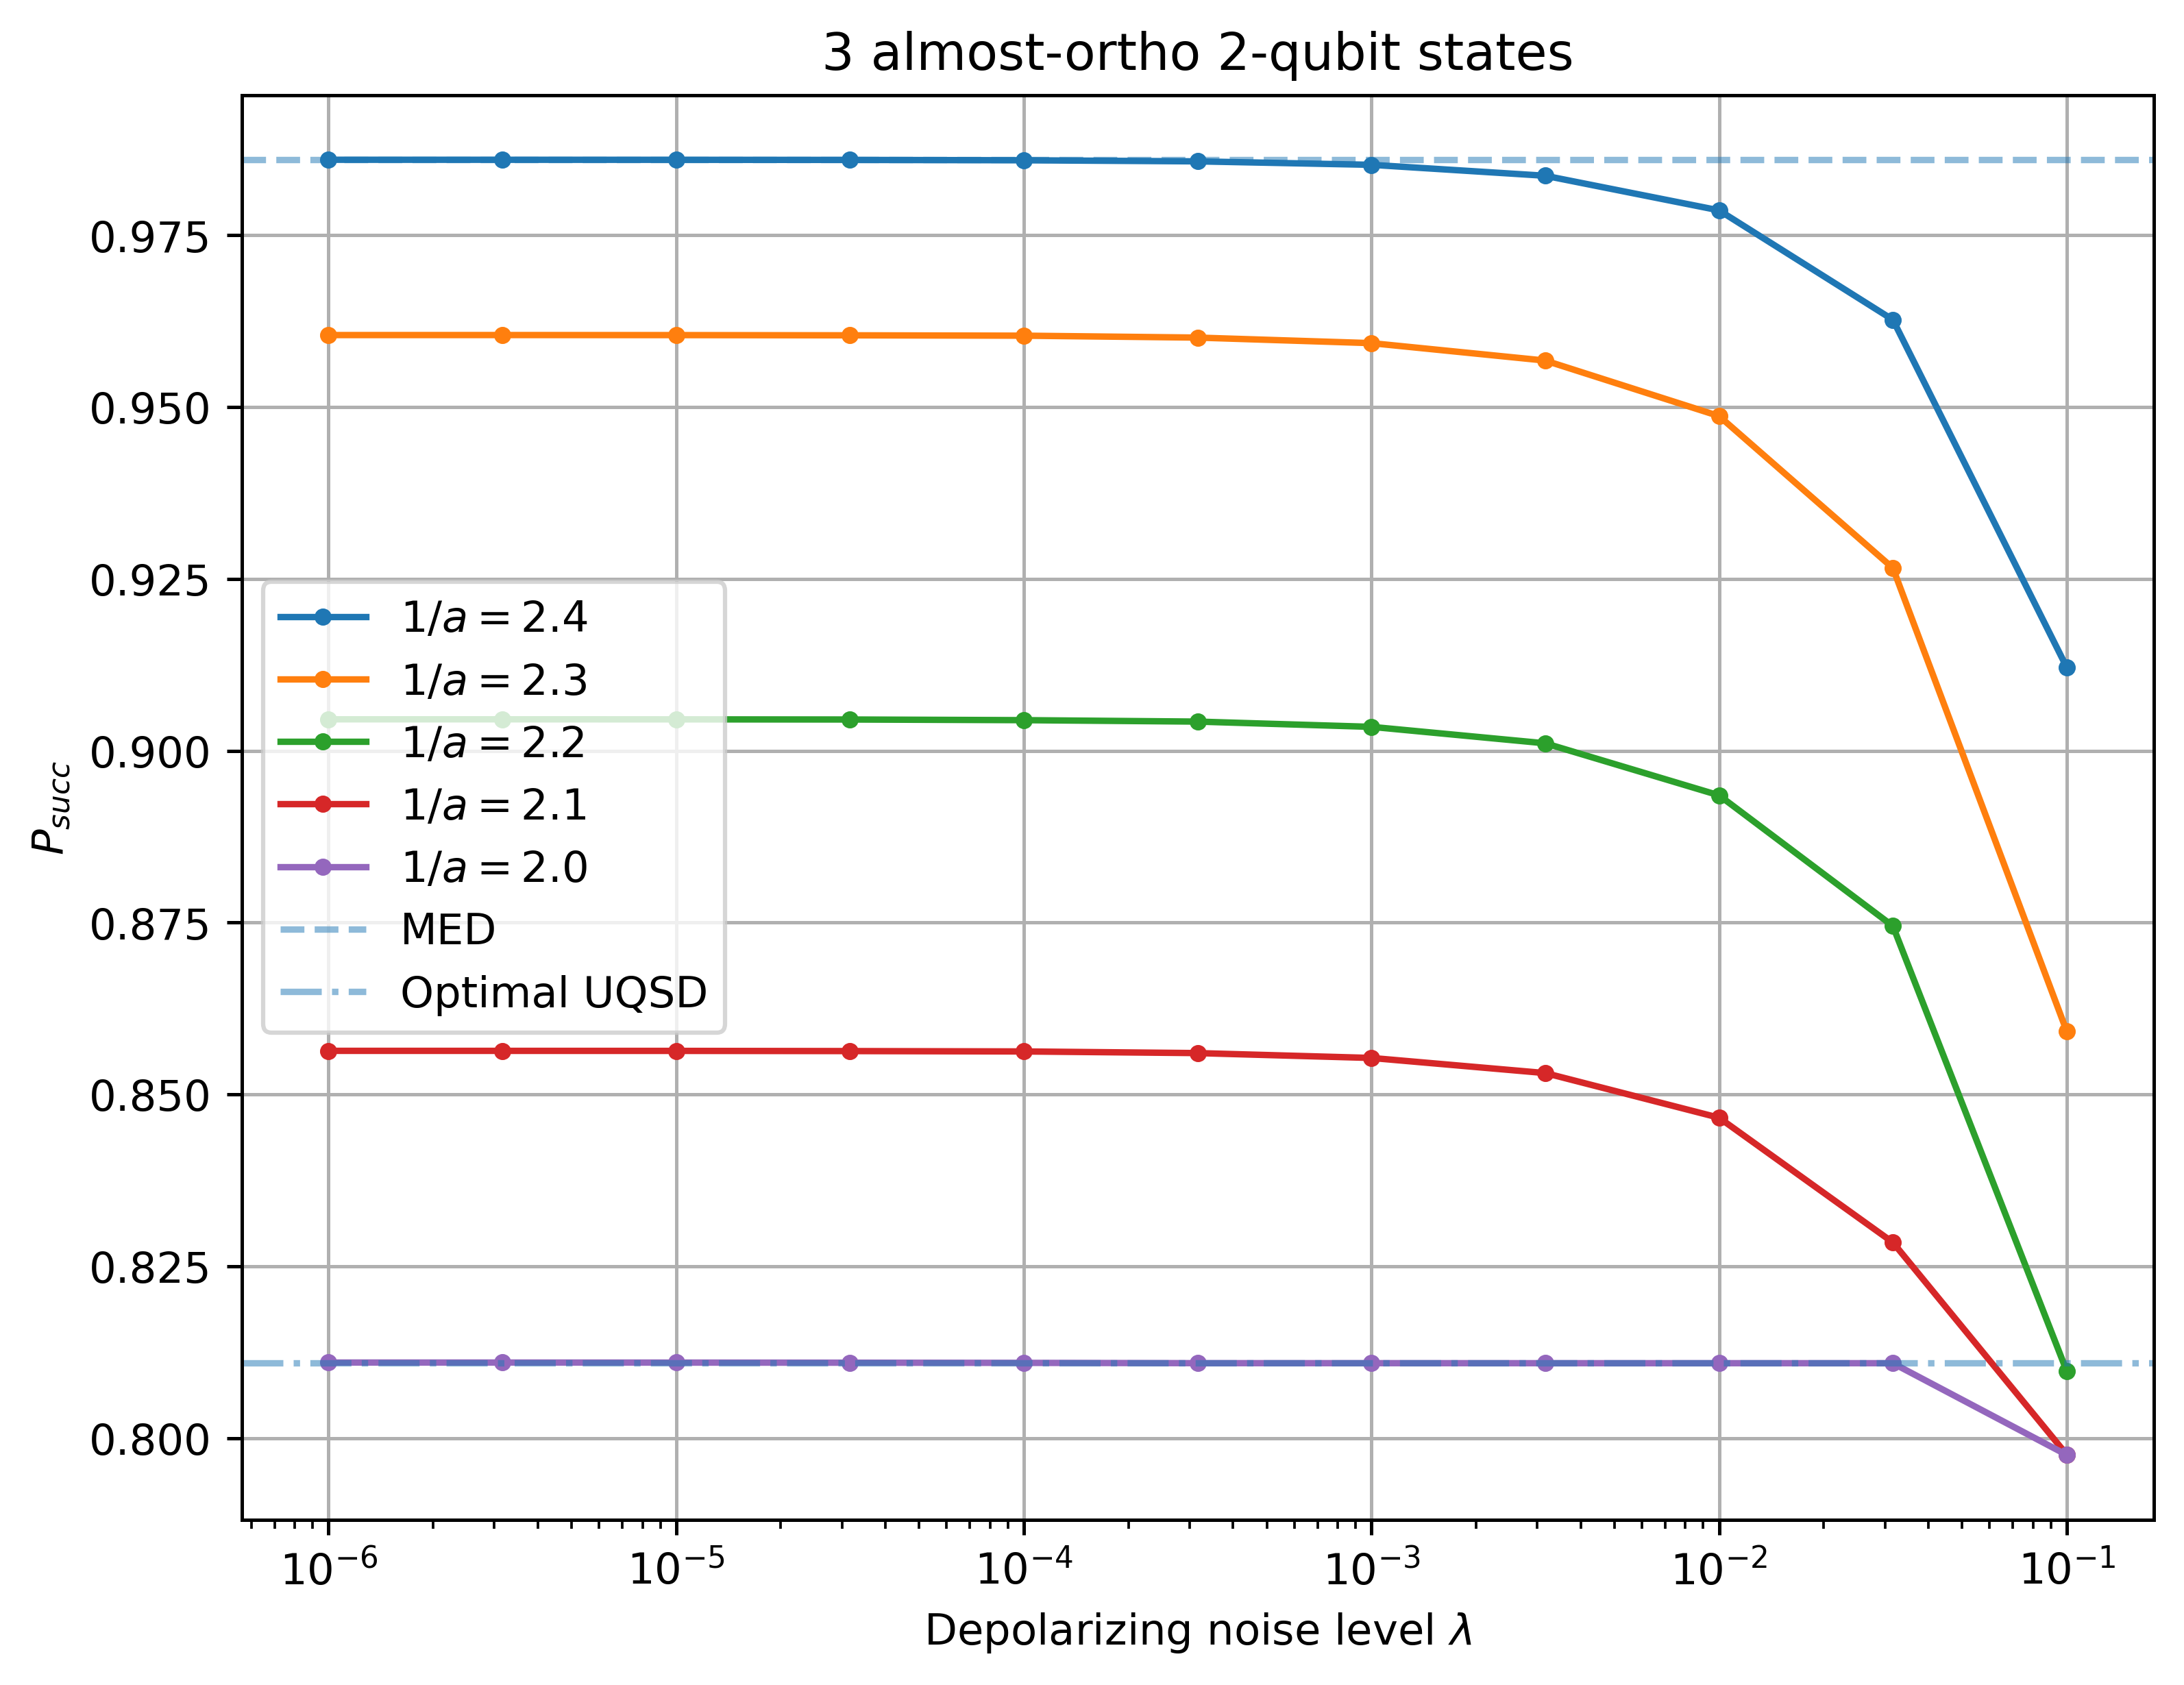

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=450)

for i, arr in enumerate(psucc_result_list):
    if i >= 6:
        plt.plot(noise_levels, arr, ".-", label=rf'$1/a = {1/lamdah_list[i]:.1f}$')
    # plt.plot(noise_levels, arr, ".-", label=rf'$1/a = {1/lamdah_list[i]:.1f}$')

plt.axhline(med_opt_val, linestyle="--", label='MED', alpha=0.5)
plt.axhline(uqsd_opt_val, linestyle="-.", label='Optimal UQSD', alpha=0.5)

plt.xlabel(r'Depolarizing noise level $\lambda$')
plt.ylabel(r'$P_{succ}$')
plt.xscale('log')

plt.title('3 almost-ortho 2-qubit states')
# plt.title('2 1-qubit states 45deg')
plt.legend()
plt.grid(True)
plt.show()

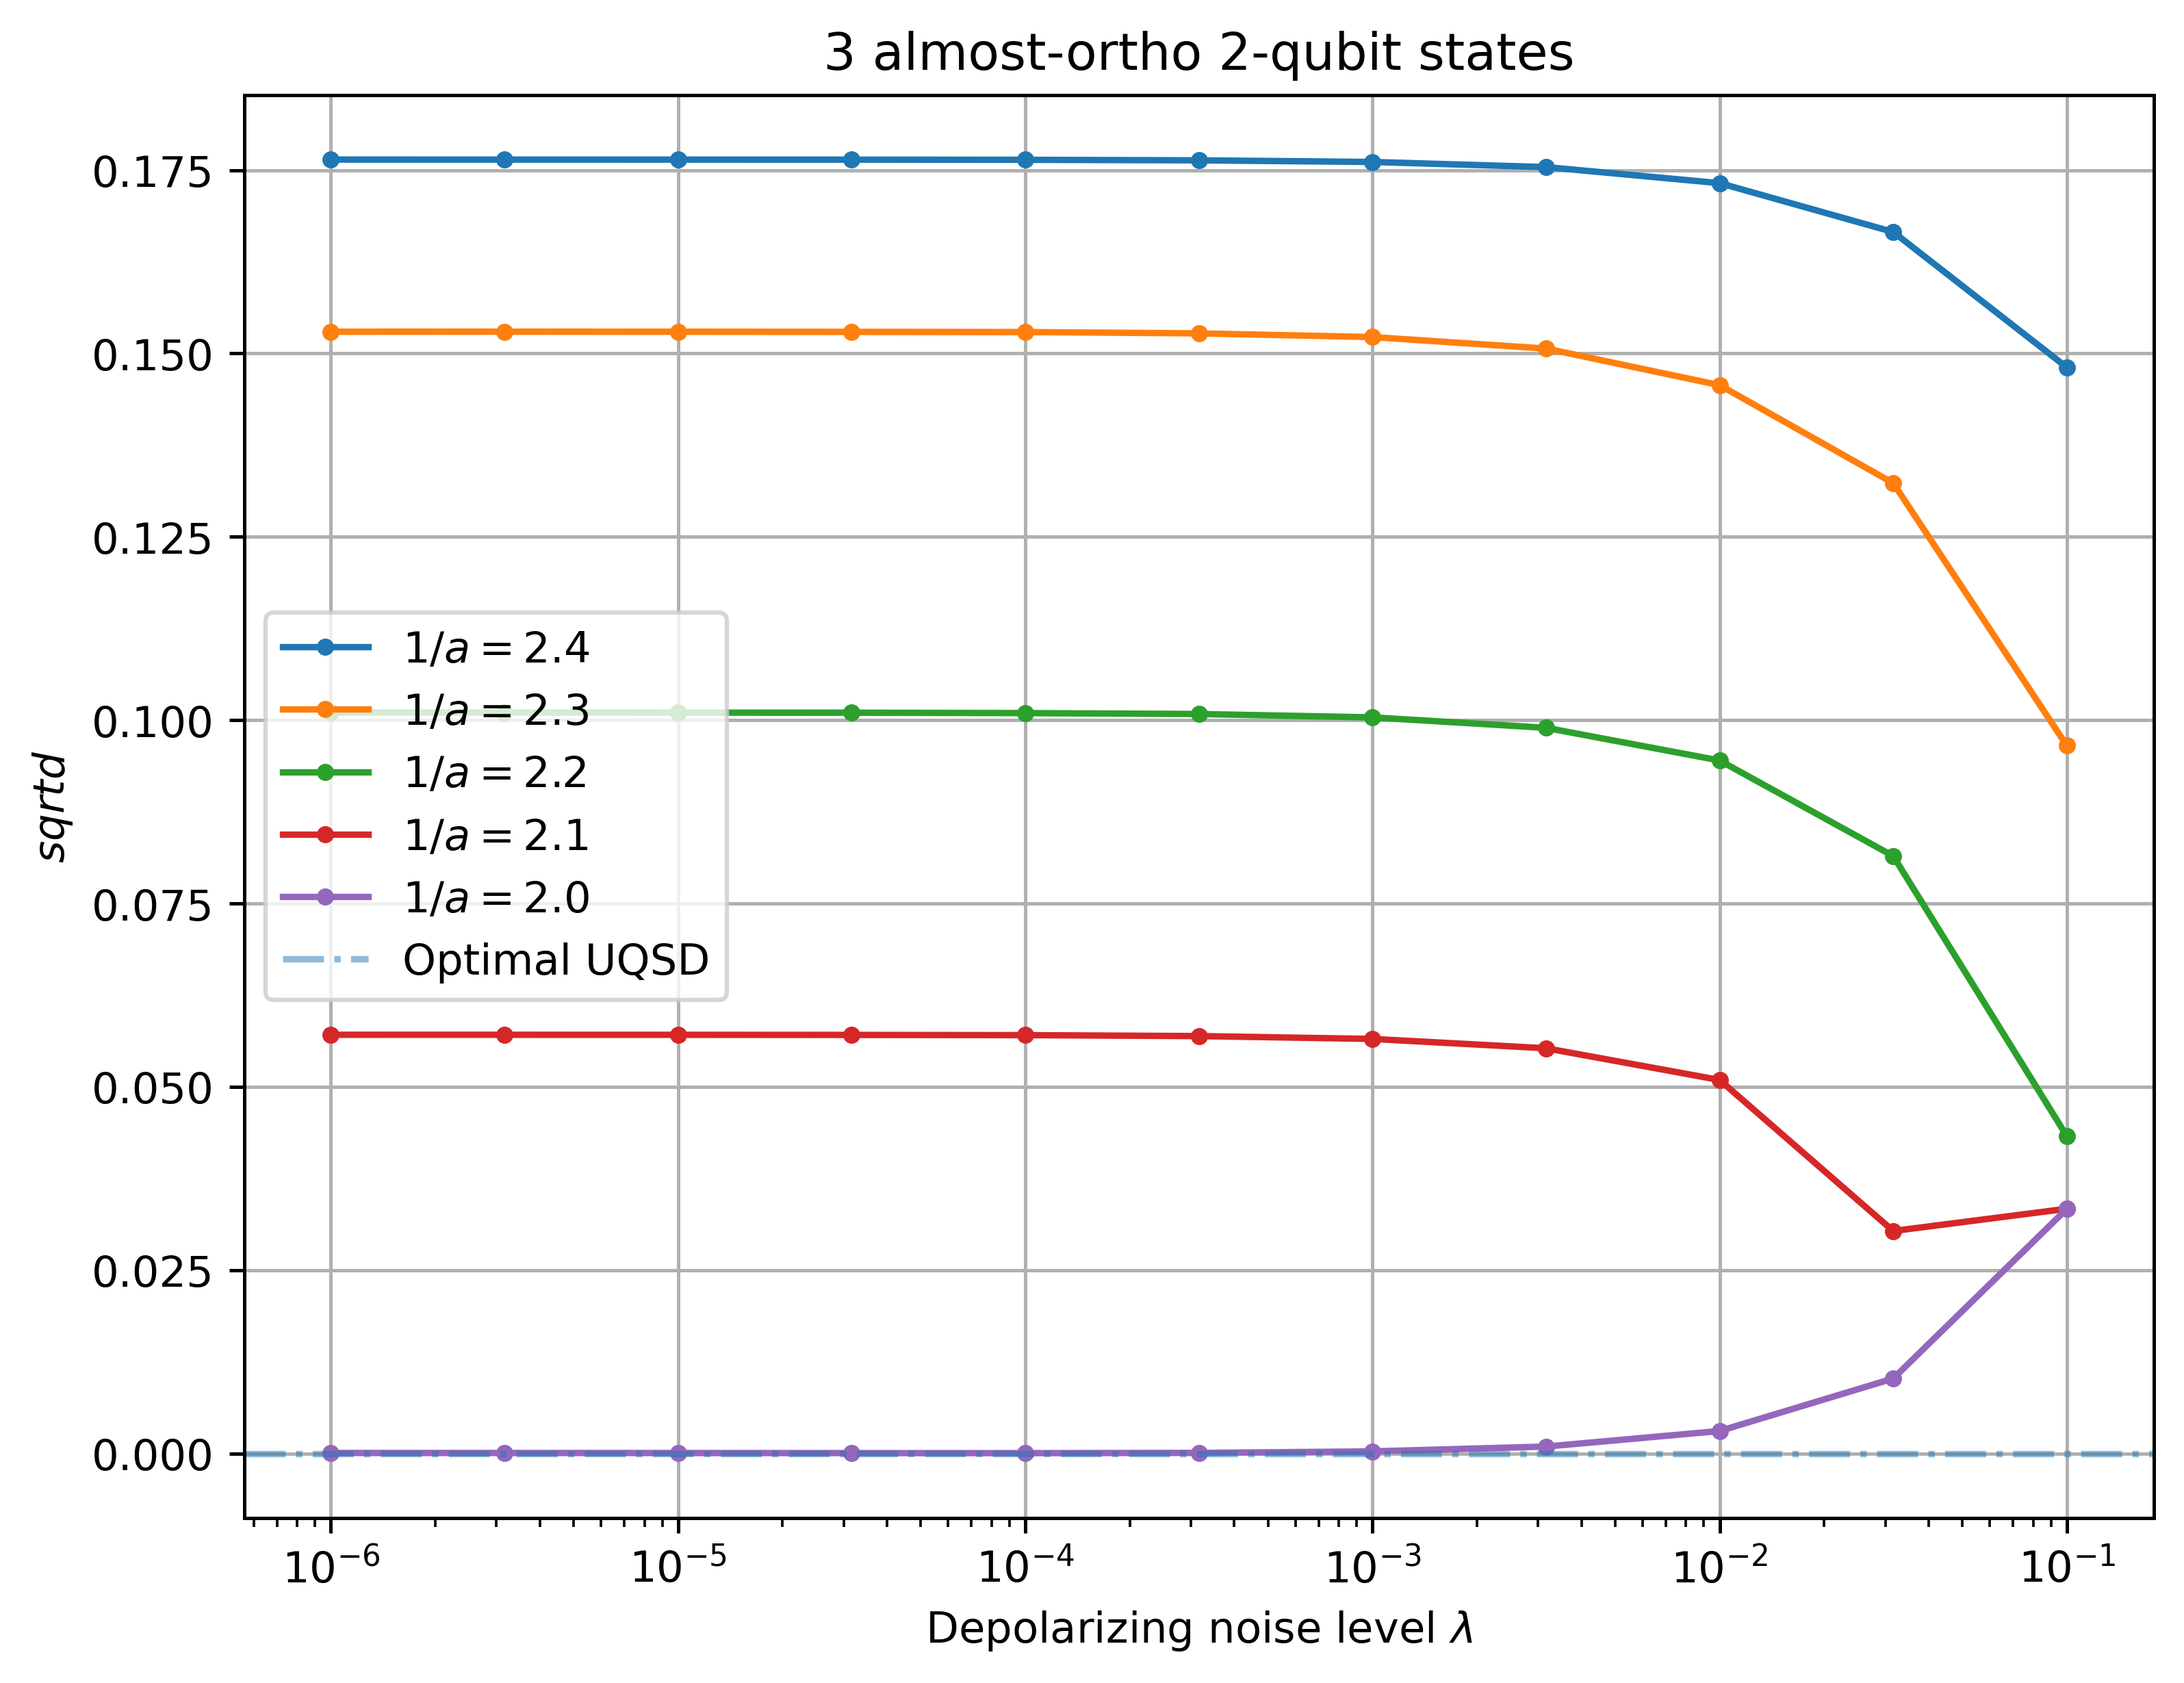

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=450)

for i, arr in enumerate(sqrtd_result_list):
    if i >= 6:
        plt.plot(noise_levels, arr, ".-", label=rf'$1/a = {1/lamdah_list[i]:.1f}$')
    # plt.plot(noise_levels, arr, ".-", label=rf'$1/a = {1/lamdah_list[i]:.1f}$')

# plt.axhline(med_opt_val, linestyle="--", label='MED', alpha=0.5)
plt.axhline(0, linestyle="-.", label='Optimal UQSD', alpha=0.5)

plt.xlabel(r'Depolarizing noise level $\lambda$')
plt.ylabel(r'$sqrtd$')
plt.xscale('log')

plt.title('3 almost-ortho 2-qubit states')
# plt.title('2 1-qubit states 45deg')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
'''
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=600)

for i, arr in enumerate(psucc_result_list):
    if (i + 1) % 2:
        plt.plot(noise_levels, arr, ".-", label=rf'$a_{1} = 0.001, a_{2} = {lamdah_list[i]:.2f}$')

plt.axhline(0.855, linestyle="--", label=rf'MED', alpha=0.5)
plt.axhline(0.292, linestyle="-.", label='Optimal UQSD', alpha=0.5)

plt.xlabel(r'Depolarizing noise level $\lambda$')
plt.ylabel(r'$P_{succ}$')
plt.xscale('log')
plt.title('Two 1-qubit states 45deg')
plt.legend()
plt.grid(True)
plt.show()
'''

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4597/2895342537.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(r'Depolarizing noise level $\lambda$')


'\nimport matplotlib.pyplot as plt\n\nplt.figure(figsize=(8, 6), dpi=600)\n\nfor i, arr in enumerate(psucc_result_list):\n    if (i + 1) % 2:\n        plt.plot(noise_levels, arr, ".-", label=rf\'$a_{1} = 0.001, a_{2} = {lamdah_list[i]:.2f}$\')\n\nplt.axhline(0.855, linestyle="--", label=rf\'MED\', alpha=0.5)\nplt.axhline(0.292, linestyle="-.", label=\'Optimal UQSD\', alpha=0.5)\n\nplt.xlabel(r\'Depolarizing noise level $\\lambda$\')\nplt.ylabel(r\'$P_{succ}$\')\nplt.xscale(\'log\')\nplt.title(\'Two 1-qubit states 45deg\')\nplt.legend()\nplt.grid(True)\nplt.show()\n'

In [41]:
state_vec

[Statevector([0.9806+0.j, 0.    +0.j, 0.    +0.j, 0.1961+0.j],
             dims=(2, 2)),
 Statevector([0.    +0.j, 0.8944+0.j, 0.    +0.j, 0.4472+0.j],
             dims=(2, 2)),
 Statevector([0.    +0.j, 0.    +0.j, 0.8192+0.j, 0.5735+0.j],
             dims=(2, 2))]

In [42]:
import pandas as pd

# Assuming psucc_result_list, noise_levels, and lamdah_list are defined
# Create a DataFrame with noise_levels as index and each array in psucc_result_list as a column
df = pd.DataFrame(
    {f'a_2={lamdah_list[i]:.2f}': arr for i, arr in enumerate(psucc_result_list)},
    index=noise_levels
)

# Save to CSV
df.to_csv('psucc_results_3states.csv', index_label='noise_level')

In [43]:
'''
from flow.solve_mix import *
from utils.handy_states import *

# states = state_dict["states"]
states = [
    Statevector([1, 0]),
    Statevector([1/np.sqrt(2), 1/np.sqrt(2)]),
]
# get_Phi_tilde
tmp_arr = []
for s in states:
    tmp_arr.append(s)
Phi = np.transpose(tmp_arr)
print("Phi")
print(Phi)
Phi_tilde = np.matmul(Phi, np.linalg.inv(np.matmul(Phi.conj().T, Phi)))
Phi_tilde = Phi_tilde.round(15)  # Remove nearzero value
Phi_tilde = Phi_tilde.T
print("Phi_tilde")
print(Phi_tilde)
'''

'\nfrom flow.solve_mix import *\nfrom utils.handy_states import *\n\n# states = state_dict["states"]\nstates = [\n    Statevector([1, 0]),\n    Statevector([1/np.sqrt(2), 1/np.sqrt(2)]),\n]\n# get_Phi_tilde\ntmp_arr = []\nfor s in states:\n    tmp_arr.append(s)\nPhi = np.transpose(tmp_arr)\nprint("Phi")\nprint(Phi)\nPhi_tilde = np.matmul(Phi, np.linalg.inv(np.matmul(Phi.conj().T, Phi)))\nPhi_tilde = Phi_tilde.round(15)  # Remove nearzero value\nPhi_tilde = Phi_tilde.T\nprint("Phi_tilde")\nprint(Phi_tilde)\n'

In [44]:
'''
for i in range(2):
    print(np.multiply(Phi_tilde[i][None].T.conj(), Phi_tilde[i]))
'''

'\nfor i in range(2):\n    print(np.multiply(Phi_tilde[i][None].T.conj(), Phi_tilde[i]))\n'

In [45]:
'''
problem_spec = ProblemSpec(num_qubits=num_qubits, num_states=num_states)
problem_spec.set_states(
    state_type="statevector",
    states=states,
    overwrite=True,
)
result = apply_Eldar(problem_spec=problem_spec)
result["sol"]
'''

'\nproblem_spec = ProblemSpec(num_qubits=num_qubits, num_states=num_states)\nproblem_spec.set_states(\n    state_type="statevector",\n    states=states,\n    overwrite=True,\n)\nresult = apply_Eldar(problem_spec=problem_spec)\nresult["sol"]\n'

In [46]:
'''
states = states[:2]
problem_spec = ProblemSpec(num_qubits=2, num_states=2)
problem_spec.set_states(
    state_type="statevector",
    states=states,
    overwrite=True,
)
result = apply_Eldar(problem_spec=problem_spec)

result["sol"]
'''

'\nstates = states[:2]\nproblem_spec = ProblemSpec(num_qubits=2, num_states=2)\nproblem_spec.set_states(\n    state_type="statevector",\n    states=states,\n    overwrite=True,\n)\nresult = apply_Eldar(problem_spec=problem_spec)\n\nresult["sol"]\n'